<a href="https://colab.research.google.com/github/hafizurrahman1014-sys/Machine-Learning-projects/blob/main/2131012(Hierarchical_clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

from sklearn.cluster import AgglomerativeClustering

In [15]:
df = pd.read_csv("insurance.csv")

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [16]:
X = df[['age', 'bmi', 'charges']]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

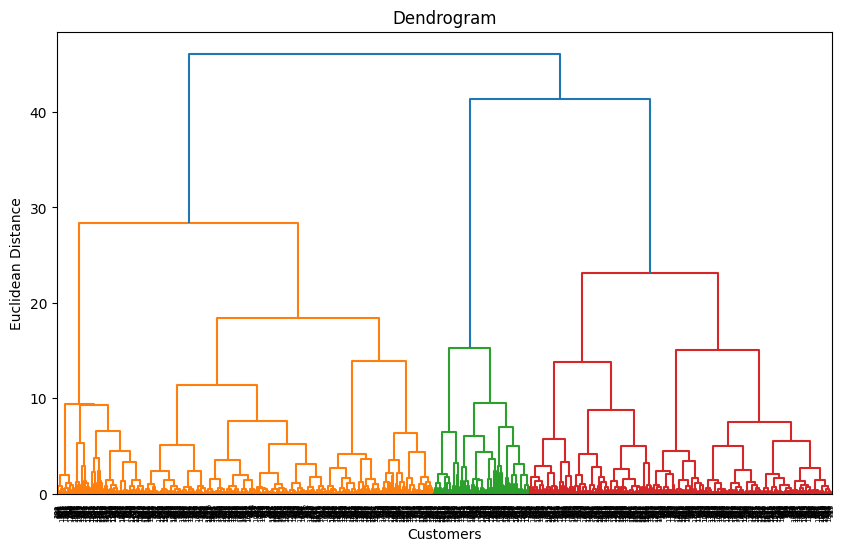

In [18]:
linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [19]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

clusters = hc.fit_predict(X_scaled)

df['Cluster'] = clusters

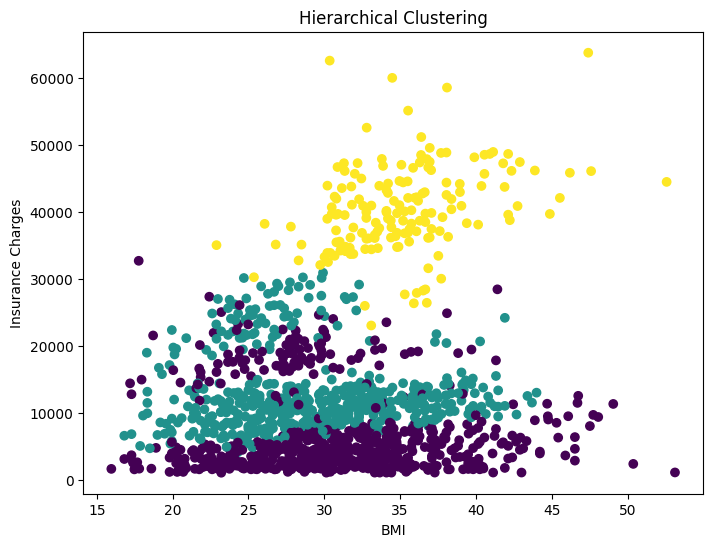

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['bmi'],
    df['charges'],
    c=df['Cluster']
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Hierarchical Clustering")

plt.show()

In [21]:
# Re-run agglomerative clustering to ensure 'clusters' exists
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
clusters = hc.fit_predict(X_scaled)

# Ensure clusters are assigned to the dataframe
df['Cluster'] = clusters

# Displaying the average characteristics of each cluster
cluster_summary = df.groupby('Cluster')[['age', 'bmi', 'charges']].mean()
display(cluster_summary)

,age,bmi,charges
Cluster,,,
0,28.831029,30.688886,6723.439668
1,51.909962,29.218305,12864.823856
2,39.957576,35.134576,40384.410390


limitation: Hierarchical Clustering is computationally expensive for large datasets because it calculates distances between many data points